# Pima Indians Diabetes Diagnostic System
### Comprehensive Data Queries, Interactive Exploratory Data Analysis with Plotly Express, Classification Pipeline, and Serialization

**Objective:**
Predict whether a patient has diabetes (Outcome = 1) or is healthy (Outcome = 0) based on clinical measurements. 

**Key Industry & Preprocessing Requirements Covered:**
1. **Interactive Analytics:** Utilizing Plotly Express for beautiful, interactive dashboards.
2. **Hidden Missing Values Handling:** Identifying invalid `0` values in clinical columns (like Glucose, BloodPressure, Insulin, and BMI) and handling them using leak-free `SimpleImputer` pipeline steps.
3. **Strict Preprocessing Isolation:** Separating train-test splits before running any scaling or imputation to prevent data leakage.
4. **Cost-Sensitive Metrics:** Evaluating models using interactive Confusion Matrices, Classification Reports (Precision, Recall, F1), and ROC-AUC curves, focusing on reducing False Negatives (Recall).
5. **Ensemble Models & Tuning:** Comparing Logistic Regression, Random Forest, and XGBoost Classifiers, followed by RandomizedSearchCV hyperparameter tuning.

## Initial Environment Setup & Data Import
First, we import the core packages, setup Plotly defaults, and download the Pima Indians Diabetes dataset from a public raw repository.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
import os

# Set Plotly template for clean academic styling
pio.templates.default = "plotly_white"

# Load Pima Indians Diabetes dataset directly from a public repository
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)
print("Diabetes Data shape:", df.shape)
display(df.head())

Diabetes Data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Part 1: Pandas Data Queries & Quantitative Analysis
Following the structure of `Data_Analysis.ipynb`, we query and aggregate the clinical log to answer key medical and diagnostic questions.

### Question 1: What is the total count and proportion of diabetic vs. healthy patients?

In [2]:
counts = df['Outcome'].value_counts()
pcts = df['Outcome'].value_counts(normalize=True) * 100

print("Quantitative Class Breakdown:")
for outcome, count in counts.items():
    label = "Diabetic" if outcome == 1 else "Healthy"
    print(f" - {label} (Outcome {outcome}): {count} records | {pcts[outcome]:.2f}%")

Quantitative Class Breakdown:
 - Healthy (Outcome 0): 500 records | 65.10%
 - Diabetic (Outcome 1): 268 records | 34.90%


### Question 2: What are the average clinical measurements (Glucose, BMI, Age, Insulin) grouped by Outcome?

In [3]:
display(df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure']].mean())

,Glucose,BMI,Age,Insulin,BloodPressure
Outcome,,,,,
0,109.980000,30.304200,31.190000,68.792000,68.184000
1,141.257463,35.142537,37.067164,100.335821,70.824627


### Question 3: Find the 10 oldest patients in the dataset. Are they mostly diabetic or healthy?

In [4]:
oldest_patients = df.sort_values(by='Age', ascending=False).head(10)
display(oldest_patients[['Age', 'Glucose', 'BMI', 'Outcome']])

,Age,Glucose,BMI,Outcome
459,81,134,25.9,0
453,72,119,19.6,0
666,70,145,32.5,1
123,69,132,26.8,0
684,69,136,0.0,0
674,68,91,35.6,0
363,67,146,38.5,1
489,67,194,26.1,0
537,67,57,21.7,0
495,66,166,26.6,0


### Question 4: Filter all patients with a BMI greater than 35 and Age greater than 50. What is their diabetes rate?

In [5]:
high_risk = df[(df['BMI'] > 35) & (df['Age'] > 50)]
total_high = len(high_risk)
diabetic_high = high_risk['Outcome'].sum()

print(f"Total high-risk patients (BMI > 35 & Age > 50): {total_high}")
print(f"Diabetic patients in this group: {diabetic_high} (Diabetes rate: {(diabetic_high/total_high)*100:.2f}%)")

Total high-risk patients (BMI > 35 & Age > 50): 23
Diabetic patients in this group: 14 (Diabetes rate: 60.87%)


### Question 5: Identifying Zeros as Missing Values
In clinical logs, missing values are sometimes recorded as `0` instead of `NaN`. Identify how many zero values exist in key clinical columns where a zero is biologically impossible (Glucose, BloodPressure, SkinThickness, Insulin, and BMI).

In [6]:
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of invalid zero values per column:")
for col in impossible_cols:
    zeros = (df[col] == 0).sum()
    print(f" - {col}: {zeros} zeros ({(zeros / len(df))*100:.2f}% of data)")

Count of invalid zero values per column:
 - Glucose: 5 zeros (0.65% of data)
 - BloodPressure: 35 zeros (4.56% of data)
 - SkinThickness: 227 zeros (29.56% of data)
 - Insulin: 374 zeros (48.70% of data)
 - BMI: 11 zeros (1.43% of data)


### Question 6: What features show the highest correlation with the Outcome target?

In [7]:
correlations = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Feature correlations with Outcome:")
print(correlations)

Feature correlations with Outcome:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


## Part 2: Interactive Visual EDA using Plotly Express
We recreate all visual layouts using **Plotly Express**, allowing interactive hovers, zooming, and category selections.

### 1. Line Chart: Diabetes Prevalence Trend by Age Group

In [8]:
# Bin Age into groups of 5 years
df['AgeGroup'] = pd.cut(df['Age'], bins=range(20, 90, 5))
age_group_stats = df.groupby('AgeGroup', observed=False)['Outcome'].mean() * 100

fig = px.line(
    x=age_group_stats.index.astype(str),
    y=age_group_stats.values,
    title='Diabetes Prevalence Trend by Age Group',
    labels={'x': 'Age Group (5-Year Bins)', 'y': 'Diabetes Percentage (%)'},
    markers=True,
    color_discrete_sequence=['#D84315']
)
fig.show()

### 2. Bar Charts (Vertical & Horizontal): Mean Glucose Levels by Outcome

In [9]:
# Filter out invalid zeros for accurate mean calculation
valid_glucose = df[df['Glucose'] > 0]
mean_glucose = valid_glucose.groupby('Outcome')['Glucose'].mean().reset_index()
mean_glucose['Outcome'] = mean_glucose['Outcome'].astype(str)

# Vertical Bar Chart
fig_v = px.bar(
    mean_glucose, x='Outcome', y='Glucose', 
    title='Mean Glucose Level by Outcome (Vertical Bar)',
    color='Outcome', color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_v.show()

# Horizontal Bar Chart
fig_h = px.bar(
    mean_glucose, y='Outcome', x='Glucose', orientation='h',
    title='Mean Glucose Level by Outcome (Horizontal Bar)',
    color='Outcome', color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_h.show()

### 3. Histogram: BMI Distribution Comparison

In [10]:
valid_bmi = df[df['BMI'] > 0].copy()
valid_bmi['Outcome'] = valid_bmi['Outcome'].astype(str)

fig = px.histogram(
    valid_bmi, x='BMI', color='Outcome',
    marginal='box', barmode='overlay',
    title='BMI Distribution Comparison Across Outcome Classes',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 4. Scatter Plot: Glucose vs. Insulin Levels

In [11]:
valid_data = df[(df['Glucose'] > 0) & (df['Insulin'] > 0)].copy()
valid_data['Outcome'] = valid_data['Outcome'].astype(str)

fig = px.scatter(
    valid_data, x='Glucose', y='Insulin', color='Outcome',
    title='Insulin vs. Glucose Scatter Plot colored by Outcome',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 5. Pie Chart: Proportions of Patient Outcomes

In [12]:
fig = px.pie(
    df, names='Outcome', 
    title='Proportional Distribution of Patient Outcomes',
    hole=0.3, color='Outcome',
    color_discrete_map={0: '#0288D1', 1: '#D84315'}
)
fig.show()

### 6. Box Plot: Range Comparison of Insulin Levels

In [13]:
valid_insulin = df[df['Insulin'] > 0].copy()
valid_insulin['Outcome'] = valid_insulin['Outcome'].astype(str)

fig = px.box(
    valid_insulin, x='Outcome', y='Insulin', color='Outcome',
    title='Outliers Analysis on Insulin Levels by Outcome Class',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 7. Countplot: Visualizing Outcome Classes

In [14]:
fig = px.histogram(
    df, x='Outcome', color='Outcome',
    title='Outcome Class Distributions',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

### 8. Barplot: Mean Insulin Level by Age Group

In [15]:
valid_ins = df[df['Insulin'] > 0].copy()
valid_ins['AgeGroup'] = valid_ins['AgeGroup'].astype(str)
mean_ins_age = valid_ins.groupby('AgeGroup')['Insulin'].mean().reset_index()

fig = px.bar(
    mean_ins_age, x='AgeGroup', y='Insulin',
    title='Mean Insulin Level by Age Group',
    color_discrete_sequence=['#0288D1']
)
fig.show()

### 9. Histplot with KDE (Plotly Density Count)

In [16]:
fig = px.histogram(
    df[df['Glucose'] > 0], x='Glucose', color='Outcome',
    marginal='rug', barmode='group',
    title='Glucose Level Distribution Grouped by Outcome',
    color_discrete_sequence=['#0288D1', '#D84315']
)
fig.show()

### 10. KDE Plot equivalent (Plotly Violin Plot)
Plotly Express represents smoothed distributions using Violin plots with embedded boxplots.

In [17]:
df_str = df.copy()
df_str['Outcome'] = df_str['Outcome'].astype(str)

fig = px.violin(
    df_str, x='Outcome', y='Age', color='Outcome',
    box=True, points='all',
    title='Patient Age Violin Density by Outcome',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 11. Boxplot & Violinplot: Glucose & BMI

In [18]:
fig_box = px.box(
    df_str[df_str['Glucose'] > 0], x='Outcome', y='Glucose', color='Outcome',
    title='Boxplot: Glucose Level by Outcome',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_box.show()

fig_viol = px.violin(
    df_str[df_str['BMI'] > 0], x='Outcome', y='BMI', color='Outcome',
    box=True,
    title='Violinplot: BMI Level by Outcome',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_viol.show()

### 12. Stripplot: SkinThickness distribution

In [19]:
fig = px.strip(
    df_str[df_str['SkinThickness'] > 0], x='Outcome', y='SkinThickness', color='Outcome',
    title='Plotly Strip Plot: Skin Thickness Measurements across Outcomes',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 13. Jointplot equivalent: Scatter with marginal histograms

In [20]:
fig = px.scatter(
    df_str[(df_str['Glucose'] > 0) & (df_str['BMI'] > 0)], 
    x='Glucose', y='BMI', color='Outcome',
    marginal_x='box', marginal_y='violin',
    title='Glucose vs. BMI with Marginal Distributions',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

### 14. Pairplot: Multi-variable Scatter Matrix

In [21]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
df_pair = df[df['Insulin'] > 0][features_to_plot].copy()
df_pair['Outcome'] = df_pair['Outcome'].astype(str)

fig = px.scatter_matrix(
    df_pair, dimensions=['Glucose', 'BMI', 'Age', 'Insulin'], color='Outcome',
    title='Pairwise Interactions of Primary Clinical Indicators',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

## Part 3: Data Leakage Protection & Train-Test Splits
To prevent **Data Leakage**, we partition our dataset into training and test sets *before* performing any imputation or scaling. 

First, we remove the hourly visual helper column (`AgeGroup`) and map invalid `0` values to `NaN` so our Scikit-Learn `SimpleImputer` can catch them cleanly during the pipeline.

In [22]:
from sklearn.model_selection import train_test_split

# Drop visual helper column and separate targets
X = df.drop(columns=['Outcome', 'AgeGroup'])
y = df['Outcome']

# Replace biologically impossible zeros with NaN
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[impossible_cols] = X[impossible_cols].replace(0, np.nan)

# Stratified Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set Features Shape:", X_train.shape)
print("Testing Set Features Shape:", X_test.shape)
print("\nNull values present in training split after NaN replacement:")
print(X_train.isnull().sum())

Training Set Features Shape: (614, 8)
Testing Set Features Shape: (154, 8)

Null values present in training split after NaN replacement:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


## Part 4: Modular Preprocessing Pipeline
We build a pipeline utilizing `SimpleImputer` with a `'median'` strategy to impute missing NaNs safely, followed by a `StandardScaler` to normalize features.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([ 
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit preprocessor strictly on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessed training features shape:", X_train_processed.shape)
print("Confirming zero null values remain:", np.isnan(X_train_processed).sum())

Preprocessed training features shape: (614, 8)
Confirming zero null values remain: 0


## Part 5: Data Sampling Bias Assessment
Before building models, we must audit our train-test split for **Selection Bias** or **Covariate Shift**:
1. **Class Stratification Audit:** Confirming that the target class proportions remain identical across splits.
2. **Feature Distribution Audit:** Confirming that the training and testing sets share the same mathematical distributions (means and standard deviations), verifying that our splits are unbiased.

In [24]:
# 1. Class Distribution Stratification Check
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100
orig_pct = y.value_counts(normalize=True) * 100

bias_class_df = pd.DataFrame({
    'Original Dataset (%)': orig_pct,
    'Training Split (%)': train_pct,
    'Testing Split (%)': test_pct
})
print("=== Class Stratification Bias Audit ===")
display(bias_class_df)

# 2. Feature Distribution Audit (Checking for Selection Bias)
train_means = X_train.mean()
test_means = X_test.mean()
train_stds = X_train.std()
test_stds = X_test.std()

bias_feature_df = pd.DataFrame({
    'Train Mean': train_means,
    'Test Mean': test_means,
    'Train Std': train_stds,
    'Test Std': test_stds,
    'Abs Mean Difference': (train_means - test_means).abs()
})
print("\n=== Feature Distribution Bias Audit (Train vs. Test) ===")
display(bias_feature_df)

=== Class Stratification Bias Audit ===


,Original Dataset (%),Training Split (%),Testing Split (%)
Outcome,,,
0,65.104167,65.14658,64.935065
1,34.895833,34.85342,35.064935



=== Feature Distribution Bias Audit (Train vs. Test) ===


,Train Mean,Test Mean,Train Std,Test Std,Abs Mean Difference
Pregnancies,3.819218,3.948052,3.314148,3.591552,0.128834
Glucose,121.701639,121.627451,30.099771,32.317887,0.074188
BloodPressure,72.145516,73.485915,12.512061,11.807400,1.340399
SkinThickness,29.059226,29.558824,10.519221,10.334575,0.499598
Insulin,149.077160,185.500000,107.234748,159.423395,36.422840
BMI,32.448926,32.491447,6.874773,7.144469,0.042522
DiabetesPedigreeFunction,0.477428,0.449740,0.330300,0.335567,0.027688
Age,33.366450,32.740260,11.833438,11.487877,0.626190


## Part 6: Baseline Model Building (Train-Test Validation)
We train 8 different classification algorithms on the training split, predict on the test split, and compile our metrics (Accuracy, Precision, Recall, F1, ROC-AUC) into a results dictionary.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute class scale weight for XGBoost
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize the 8 classifiers
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
}

baseline_results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_processed, y_train)
    
    # Predict on train and test
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    y_pred_prob = model.predict_proba(X_test_processed)[:, 1]
    
    # F1 scores for diagnostics
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    gap = train_f1 - test_f1
    
    # Fit status rules
    if train_f1 < 0.60 and test_f1 < 0.60:
        fit_status = 'Underfitting'
    elif gap > 0.12:
        fit_status = 'Overfitting'
    else:
        fit_status = 'Balanced'
    
    # Save metrics
    baseline_results[name] = {
        "Train F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": gap,
        "Fit Status": fit_status,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_prob)
    }

baseline_df = pd.DataFrame(baseline_results).T.sort_values(by="Test F1", ascending=False)
print("=== Baseline Models (Diagnostics & Fit Status) ===")
display(baseline_df)

=== Baseline Models (Diagnostics & Fit Status) ===


,Train F1,Test F1,F1 Gap,Fit Status,Accuracy,Precision,Recall,ROC-AUC
Support Vector Machine,0.769556,0.65,0.119556,Balanced,0.727273,0.590909,0.722222,0.813889
Logistic Regression,0.672566,0.649573,0.022994,Balanced,0.733766,0.603175,0.703704,0.812593
K-Nearest Neighbors,0.745763,0.634615,0.111147,Balanced,0.753247,0.66,0.611111,0.789907
XGBoost,1.0,0.634615,0.365385,Overfitting,0.753247,0.66,0.611111,0.817222
Gradient Boosting,0.887255,0.626263,0.260992,Overfitting,0.75974,0.688889,0.574074,0.830556
Random Forest,1.0,0.613861,0.386139,Overfitting,0.746753,0.659574,0.574074,0.810833
AdaBoost,0.714286,0.613861,0.100424,Balanced,0.746753,0.659574,0.574074,0.817963
Decision Tree,1.0,0.541667,0.458333,Overfitting,0.714286,0.619048,0.481481,0.660741


## Part 7: Validation Strategy Analysis (K-Fold vs. Stratified K-Fold vs. Repeated Stratified K-Fold)
To prove validation stability and prevent overfitting, we compare three cross-validation strategies using F1-score as our evaluation metric:
1. **Standard K-Fold:** Splitting data without looking at class ratios.
2. **Stratified K-Fold:** Keeping the minority/majority target proportions constant in each fold.
3. **Repeated Stratified K-Fold:** Running stratified K-Fold multiple times with different random shuffles to establish robust error bounds.

In [26]:
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score

# Define cross validation splitting strategies
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rep_skfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

cv_comparison = {}

for name, model in models.items():
    # 1. K-Fold CV
    kf_scores = cross_val_score(model, X_train_processed, y_train, cv=kfold, scoring='f1', n_jobs=-1)
    
    # 2. Stratified K-Fold CV
    skf_scores = cross_val_score(model, X_train_processed, y_train, cv=skfold, scoring='f1', n_jobs=-1)
    
    # 3. Repeated Stratified K-Fold CV
    rep_skf_scores = cross_val_score(model, X_train_processed, y_train, cv=rep_skfold, scoring='f1', n_jobs=-1)
    
    # Store results
    cv_comparison[name] = {
        "K-Fold Mean F1": kf_scores.mean(),
        "K-Fold F1 Std": kf_scores.std(),
        "Stratified K-Fold Mean F1": skf_scores.mean(),
        "Stratified K-Fold F1 Std": skf_scores.std(),
        "Repeated Stratified Mean F1": rep_skf_scores.mean(),
        "Repeated Stratified F1 Std": rep_skf_scores.std()
    }

cv_df = pd.DataFrame(cv_comparison).T.sort_values(by="Stratified K-Fold Mean F1", ascending=False)
print("=== Cross-Validation Strategies Performance Comparison (F1-Score) ===")
display(cv_df)

=== Cross-Validation Strategies Performance Comparison (F1-Score) ===


,K-Fold Mean F1,K-Fold F1 Std,Stratified K-Fold Mean F1,Stratified K-Fold F1 Std,Repeated Stratified Mean F1,Repeated Stratified F1 Std
Support Vector Machine,0.676674,0.056681,0.692899,0.026234,0.693288,0.045726
Logistic Regression,0.669704,0.050450,0.672385,0.013319,0.674637,0.037372
XGBoost,0.610498,0.054188,0.639192,0.029217,0.610870,0.059042
Random Forest,0.603529,0.070334,0.633214,0.034944,0.627965,0.054564
AdaBoost,0.629713,0.082624,0.627867,0.031052,0.622119,0.047140
Gradient Boosting,0.638105,0.039347,0.620396,0.024474,0.620967,0.042254
K-Nearest Neighbors,0.601344,0.044954,0.587603,0.048950,0.607047,0.050124
Decision Tree,0.563565,0.053020,0.544266,0.056268,0.561551,0.043646


### Confusion Matrices Grid (Row-Wise Layout)
We plot the confusion matrices for all 8 baseline models in a grid layout (2 rows by 4 columns) to view their classification errors side-by-side.

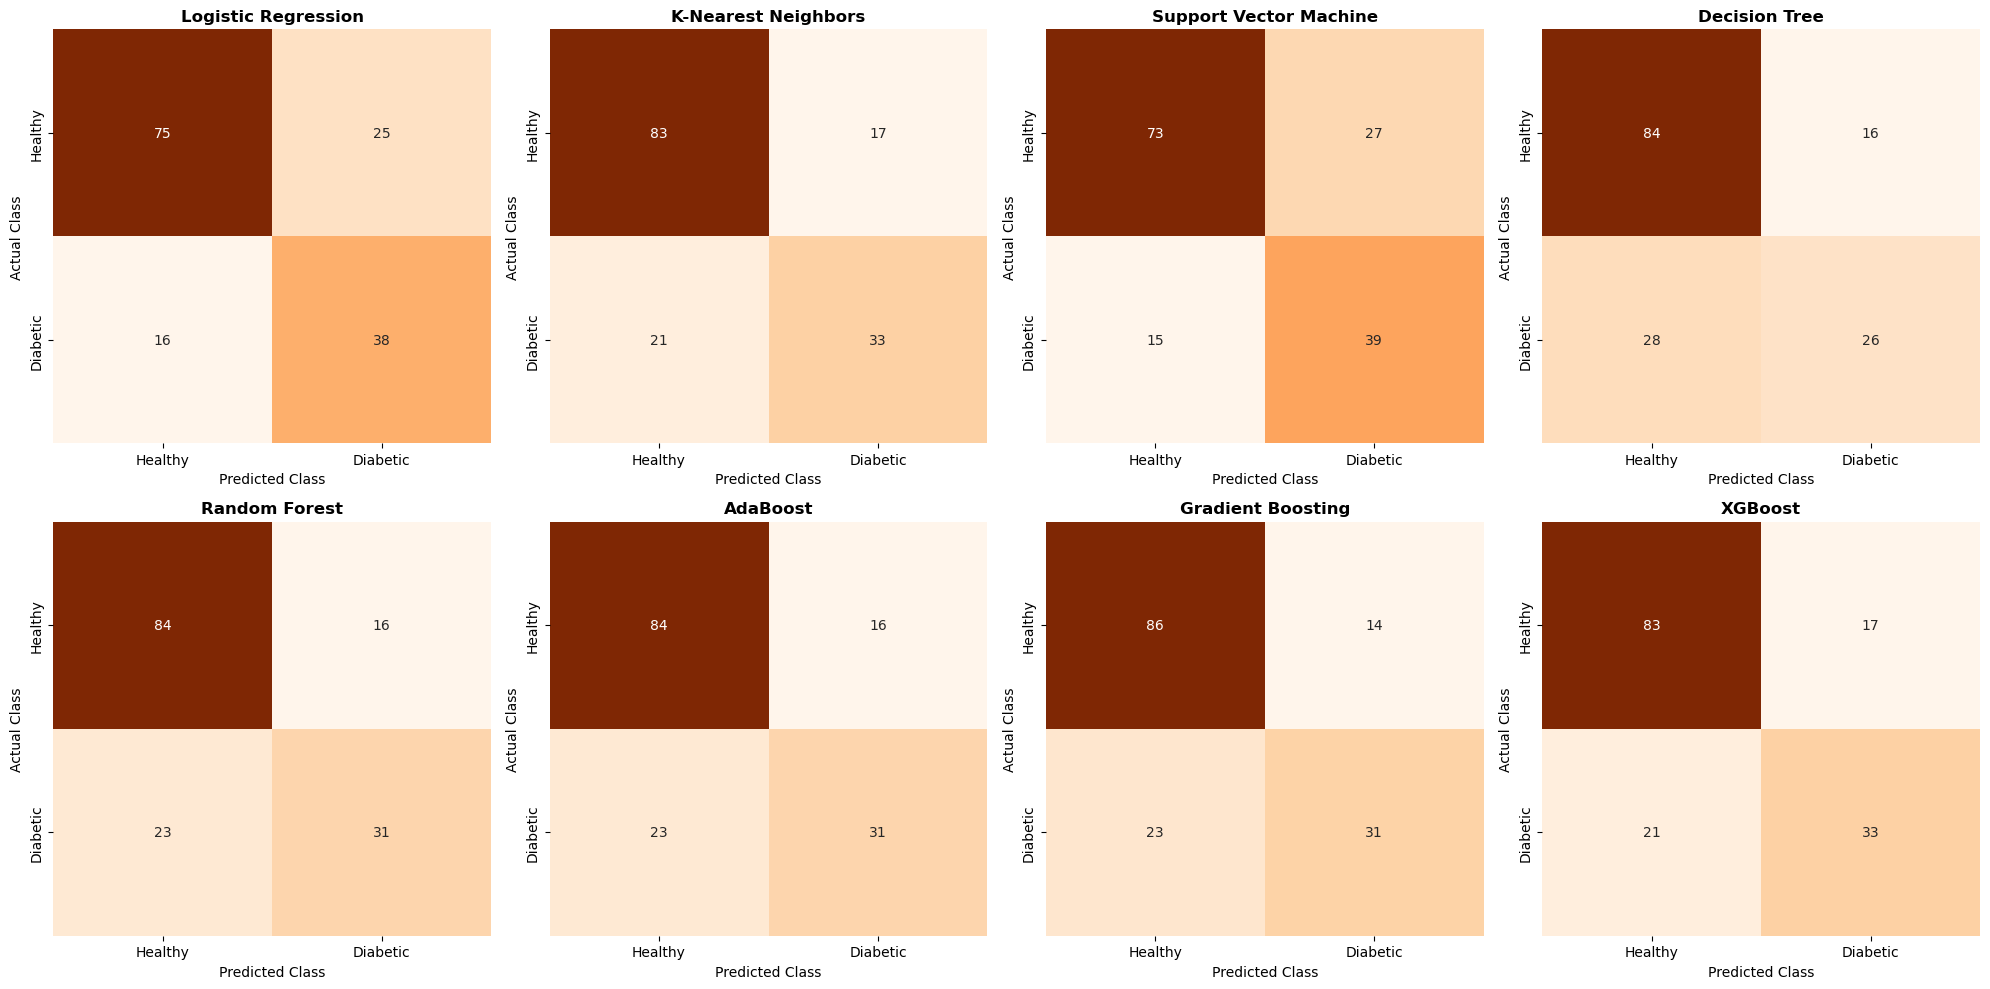

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[idx],
                xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual Class')
    axes[idx].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()

## Part 8: Model Hyperparameter Tuning
Based on the cross-validation comparison, we select the top-performing generalizable model (XGBoost) and optimize its parameters using `RandomizedSearchCV`.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_processed, y_train)
best_model = random_search.best_estimator_

print("Best Hyperparameters Found:", random_search.best_params_)
y_tuned_pred = best_model.predict(X_test_processed)
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_tuned_pred))

Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05}
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



## Part 9: Serialization & Export
Finally, we bundle the preprocessing steps and the tuned model into a single pipeline, serialize it, and export it using `joblib` so it can be deployed on servers (like a Streamlit Cloud app).

In [29]:
import joblib

# Create full inference pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Export files
joblib.dump(full_pipeline, 'best_diabetes_model.pkl')
print("Full model pipeline successfully saved as best_diabetes_model.pkl!")

Full model pipeline successfully saved as best_diabetes_model.pkl!
